# COPD Risk Prediction
Menna Allah AlSayed

This notebook is an end-to-end machine-learning pipeline for predicting whether a person
reports COPD, emphysema, or chronic bronchitis using BRFSS 2022 health-survey responses.

All code runs from this notebook against the cleaned dataset at
`data/brfss2022_copd_model.csv`. Outputs (model + threshold + metadata) are written
to the project root and consumed by the Flask app in `app.py`.

## Step 1 - Project Understanding

**Problem.** COPD (chronic obstructive pulmonary disease) is a chronic lung condition that
makes breathing progressively harder. Early risk screening helps direct people to medical
follow-up before symptoms become severe.

**Question.** Can we predict whether a respondent reports COPD using only self-reported
health-survey answers (no spirometry, no lab results)?

**Approach.** Supervised binary classification on the BRFSS 2022 dataset. The positive class
is rare (~8 percent), so we use class-balanced models, ROC-AUC for selection, and tune the
decision threshold on F1-score.

## Step 2 - Imports and Configuration

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 60)

RANDOM_STATE = 42
MAX_TRAIN_ROWS = 120_000  # stratified sample cap for speed
TARGET = 'COPD'

# Unified figure palette (color-blind friendly).
COPD_NEG = '#1f766f'   # teal      -> No COPD (negative class)
COPD_POS = '#e07a5f'   # coral     -> COPD     (positive class)
ACCENT   = '#234e70'   # deep navy -> single-line accent
NEUTRAL  = '#3d405b'   # slate     -> threshold marker
EDGE     = '#2b2d42'   # near-black bar edges
METRIC_PALETTE = ['#234e70', '#1f766f', '#81b29a', '#f2cc8f', '#e07a5f']

DATA_PATH = Path('data') / 'brfss2022_copd_model.csv'
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)
print('Project root :', Path('.').resolve().name)
print('Data path    :', DATA_PATH)

Project root : ML_Project
Data path    : data\brfss2022_copd_model.csv


## Step 3 - Load the Dataset

The cleaned CSV was produced from the raw BRFSS 2022 zip by `build_copd_risk_project.py`.
Steps that script performs (kept outside the notebook because the raw zip is large):

- keep only rows with valid `CHCCOPD3` (1 = Yes, 2 = No)
- map BRFSS coded values (state, age group, education, etc.) to readable labels
- recode 88-day fields as 0, 77/99 as missing for `PHYSHLTH`, `MENTHLTH`, `AVEDRNK3`
- rescale BMI from `_BMI5` (it is stored multiplied by 100)
- keep `Unknown` as an explicit category for predictors with refusals

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Rows    : {len(df):,}')
print(f'Columns : {df.shape[1]}')
df.head()

Rows    : 442,913
Columns : 48


,COPD,State,Sex,AgeGroup,Age,GeneralHealth,PhysicalHealthDays,MentalHealthDays,HasPersonalDoctor,CouldNotAffordDoctor,RecentCheckup,ExercisePastMonth,SleepHours,HeartAttack,CoronaryHeartDisease,Stroke,AsthmaEver,AsthmaCurrent,Depression,KidneyDisease,Arthritis,Diabetes,MaritalStatus,Education,Employment,Income,Deaf,Blind,DifficultyDeciding,DifficultyWalking,DifficultyDressing,DifficultyAlone,Smoked100,SmokingFrequency,SmokelessTobacco,AlcoholPast30Days,AvgDrinksPerOccasion,BMI,BMICategory,CurrentSmokerFlag,CurrentECigFlag,NoPhysicalActivityFlag,FairPoorHealthFlag,PhysicalDistressFlag,MentalDistressFlag,HasInsuranceFlag,Age18To64InsuranceFlag,HeartDiseaseFlag
0,0,Alabama,Female,80+,80.0,Very good,0.0,0.0,One,No,Within past year,No,8.0,No,No,No,No,Unknown,No,No,No,Yes,Married,College graduate,Retired,Unknown,No,No,No,No,No,No,No,Unknown,Not at all,No,NaN,NaN,Unknown,Yes,Yes,No,Yes,Yes,Yes,Unknown,Unknown,No
1,0,Alabama,Female,80+,80.0,Excellent,0.0,0.0,More than one,No,Never,No,6.0,No,No,No,No,Unknown,No,No,No,No,Widowed,High school graduate,Self-employed,"$25,000-$35,000",No,No,No,No,No,No,No,Unknown,Not at all,No,NaN,26.57,Overweight,Yes,Yes,No,Yes,Yes,Yes,Yes,Unknown,No
2,0,Alabama,Female,55-59,56.0,Very good,2.0,3.0,One,No,Within past year,Yes,5.0,No,No,No,No,Unknown,No,No,No,No,Married,College graduate,Retired,"$150,000-$200,000",No,No,No,No,No,No,No,Unknown,Not at all,No,NaN,25.61,Overweight,Yes,Yes,Yes,Yes,No,No,Yes,Yes,No
3,0,Alabama,Female,Unknown,73.0,Excellent,0.0,0.0,One,No,Within past year,Yes,7.0,No,No,No,Yes,Yes,No,No,Yes,No,Married,High school graduate,Retired,Unknown,No,No,No,No,No,No,Yes,Some days,Not at all,No,NaN,23.30,Normal weight,No,Yes,Yes,Yes,Yes,Yes,Unknown,Unknown,No
4,0,Alabama,Female,40-44,43.0,Fair,2.0,0.0,More than one,No,Within past year,Yes,9.0,No,No,No,No,Unknown,No,No,No,No,Married,Some college,Homemaker,"$25,000-$35,000",No,No,No,No,No,No,No,Unknown,Not at all,Yes,2.0,21.77,Normal weight,Yes,Yes,Yes,No,No,Yes,Yes,Yes,No


### Quick data quality check

In [3]:
print('Target distribution:')
print(df[TARGET].value_counts().rename({0: 'No COPD', 1: 'COPD'}))
positive_rate = df[TARGET].mean()
print(f'\nPositive class rate: {positive_rate:.2%}')
print('\nMissing values (top 10 columns):')
missing = df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False).head(10))

Target distribution:
COPD
No COPD    407257
COPD        35656
Name: count, dtype: int64

Positive class rate: 8.05%

Missing values (top 10 columns):


AvgDrinksPerOccasion    235837
BMI                      48294
PhysicalHealthDays       10665
MentalHealthDays          8819
SleepHours                5247
dtype: int64


## Step 4 - Exploratory Data Analysis

We look at the target balance, age and BMI distributions, and how COPD prevalence varies
with smoking and self-rated general health. The same plots are saved into `figures/` so
they can be reused in the report and the Flask UI.

### 4.1 Target distribution

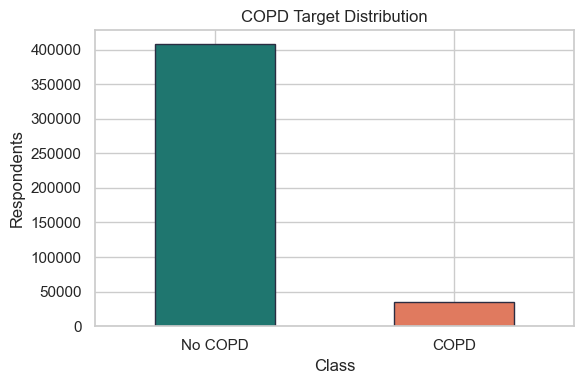

In [4]:
target_label = df[TARGET].map({0: 'No COPD', 1: 'COPD'})

fig, ax = plt.subplots(figsize=(6, 4))
target_label.value_counts().plot(
    kind='bar', color=[COPD_NEG, COPD_POS], edgecolor=EDGE, ax=ax
)
ax.set_title('COPD Target Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Respondents')
ax.tick_params(axis='x', rotation=0)
fig.tight_layout()
fig.savefig(FIG_DIR / '01_target_distribution.png', dpi=150)
plt.show()

### 4.2 Age distribution by COPD status

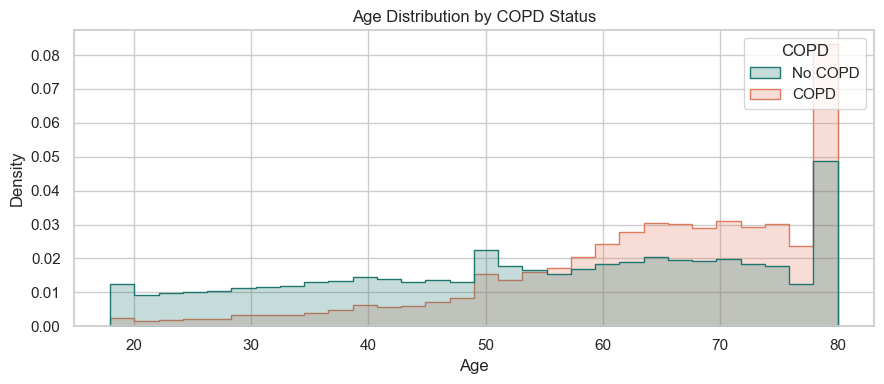

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(
    data=df, x='Age', hue=target_label, bins=30,
    element='step', stat='density', common_norm=False, ax=ax,
    palette={'No COPD': COPD_NEG, 'COPD': COPD_POS},
)
ax.set_title('Age Distribution by COPD Status')
fig.tight_layout()
fig.savefig(FIG_DIR / '02_age_distribution.png', dpi=150)
plt.show()

### 4.3 BMI by COPD status

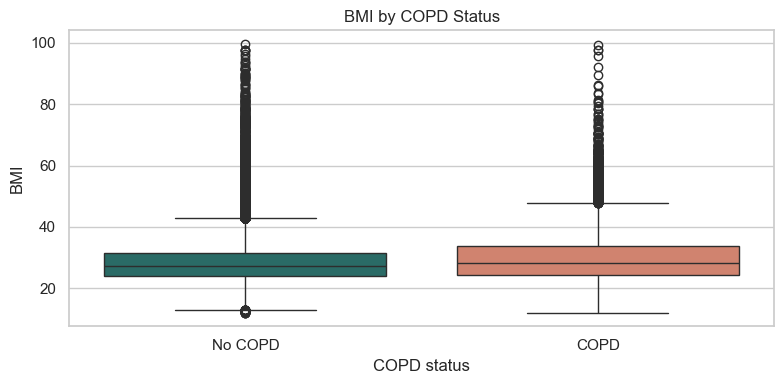

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(
    data=df, x=target_label, y='BMI', ax=ax,
    hue=target_label, legend=False,
    palette={'No COPD': COPD_NEG, 'COPD': COPD_POS},
)
ax.set_title('BMI by COPD Status')
ax.set_xlabel('COPD status')
fig.tight_layout()
fig.savefig(FIG_DIR / '03_bmi_boxplot.png', dpi=150)
plt.show()

### 4.4 COPD rate by smoking frequency

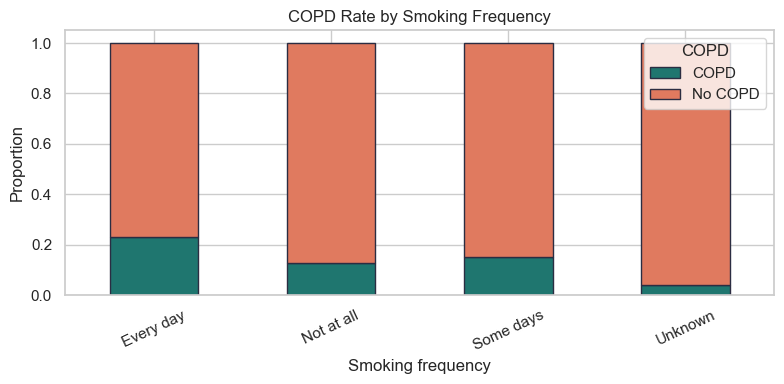

In [7]:
smoking = pd.crosstab(df['SmokingFrequency'], target_label, normalize='index')
fig, ax = plt.subplots(figsize=(8, 4))
smoking.plot(kind='bar', stacked=True, color=[COPD_NEG, COPD_POS],
             edgecolor=EDGE, ax=ax)
ax.set_title('COPD Rate by Smoking Frequency')
ax.set_xlabel('Smoking frequency')
ax.set_ylabel('Proportion')
ax.tick_params(axis='x', rotation=25)
fig.tight_layout()
fig.savefig(FIG_DIR / '04_smoking_vs_copd.png', dpi=150)
plt.show()

### 4.5 COPD rate by general health

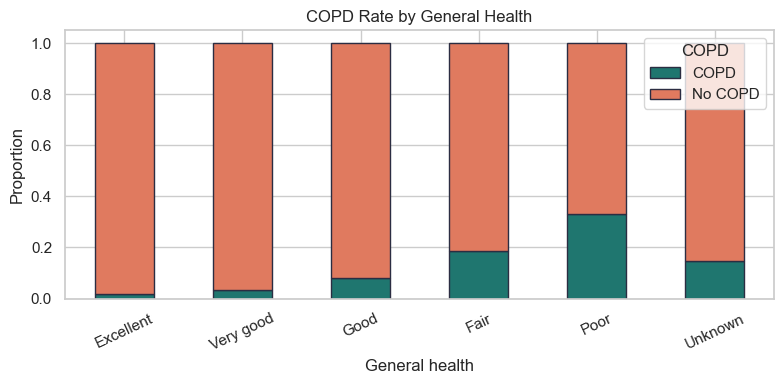

In [8]:
order = ['Excellent', 'Very good', 'Good', 'Fair', 'Poor', 'Unknown']
health = (
    pd.crosstab(df['GeneralHealth'], target_label, normalize='index')
      .reindex(order)
)
fig, ax = plt.subplots(figsize=(8, 4))
health.plot(kind='bar', stacked=True, color=[COPD_NEG, COPD_POS],
            edgecolor=EDGE, ax=ax)
ax.set_title('COPD Rate by General Health')
ax.set_xlabel('General health')
ax.set_ylabel('Proportion')
ax.tick_params(axis='x', rotation=25)
fig.tight_layout()
fig.savefig(FIG_DIR / '05_general_health_vs_copd.png', dpi=150)
plt.show()

### 4.6 Numeric feature correlation

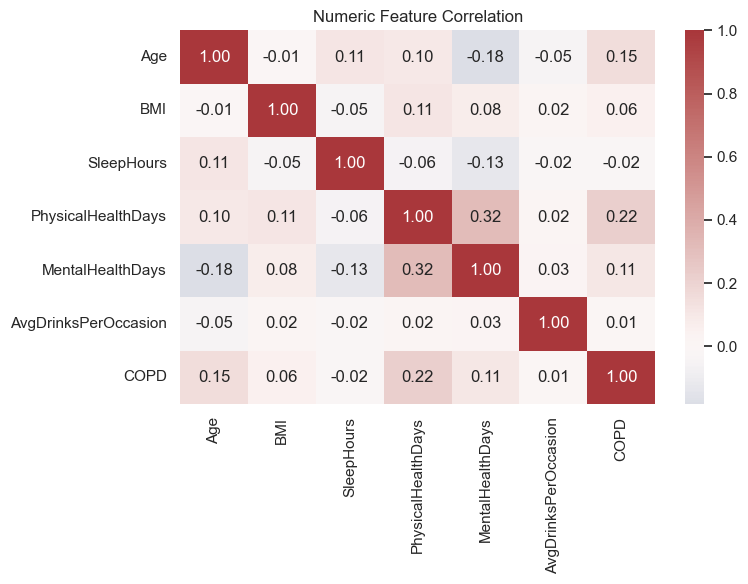

In [9]:
NUMERIC_FEATURES = [
    'Age', 'BMI', 'SleepHours',
    'PhysicalHealthDays', 'MentalHealthDays', 'AvgDrinksPerOccasion',
]

corr = df[NUMERIC_FEATURES + [TARGET]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='vlag', center=0, fmt='.2f', ax=ax)
ax.set_title('Numeric Feature Correlation')
fig.tight_layout()
fig.savefig(FIG_DIR / '06_correlation_heatmap.png', dpi=150)
plt.show()

## Step 5 - Feature Selection

We use 6 numeric features and 41 categorical features. Categorical features are kept as
readable strings (including an explicit `Unknown` level) and encoded inside the pipeline
to prevent leakage.

In [10]:
CATEGORICAL_FEATURES = [
    'State', 'Sex', 'AgeGroup', 'GeneralHealth',
    'HasPersonalDoctor', 'CouldNotAffordDoctor', 'RecentCheckup', 'ExercisePastMonth',
    'HeartAttack', 'CoronaryHeartDisease', 'Stroke',
    'AsthmaEver', 'AsthmaCurrent', 'Depression', 'KidneyDisease', 'Arthritis', 'Diabetes',
    'MaritalStatus', 'Education', 'Employment', 'Income',
    'Deaf', 'Blind', 'DifficultyDeciding', 'DifficultyWalking',
    'DifficultyDressing', 'DifficultyAlone',
    'Smoked100', 'SmokingFrequency', 'SmokelessTobacco', 'AlcoholPast30Days',
    'BMICategory',
    'CurrentSmokerFlag', 'CurrentECigFlag', 'NoPhysicalActivityFlag',
    'FairPoorHealthFlag', 'PhysicalDistressFlag', 'MentalDistressFlag',
    'HasInsuranceFlag', 'Age18To64InsuranceFlag', 'HeartDiseaseFlag',
]

FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES
print(f'Numeric features    : {len(NUMERIC_FEATURES)}')
print(f'Categorical features: {len(CATEGORICAL_FEATURES)}')
print(f'Total features      : {len(FEATURE_COLUMNS)}')

Numeric features    : 6
Categorical features: 41
Total features      : 47


## Step 6 - Train / Test Split

The full cleaned dataset has ~443k rows. We take a stratified sample of up to
120k rows to keep training fast on a laptop, then split 80/20 stratified by the target.

In [11]:
if len(df) > MAX_TRAIN_ROWS:
    frac = MAX_TRAIN_ROWS / len(df)
    sample = (
        df.groupby(TARGET, group_keys=False)[df.columns]
          .apply(lambda part: part.sample(frac=frac, random_state=RANDOM_STATE))
          .reset_index(drop=True)
    )
else:
    sample = df

X = sample[FEATURE_COLUMNS]
y = sample[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y,
)
print(f'Train rows: {len(X_train):,}   Test rows: {len(X_test):,}')
print(f'Train positive rate: {y_train.mean():.2%}')
print(f'Test  positive rate: {y_test.mean():.2%}')

Train rows: 96,000   Test rows: 24,000
Train positive rate: 8.05%
Test  positive rate: 8.05%


## Step 7 - Preprocessing Pipeline

- numeric: median imputation, then standard scaling
- categorical: most-frequent imputation, then one-hot with rare-level pruning
  (`min_frequency=50`) and `handle_unknown='ignore'` so the deployed model
  tolerates unseen levels

In [12]:
def build_pipeline(estimator):
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=50)),
    ])
    preprocessor = ColumnTransformer([
        ('num', numeric_pipeline, NUMERIC_FEATURES),
        ('cat', categorical_pipeline, CATEGORICAL_FEATURES),
    ])
    return Pipeline([('preprocess', preprocessor), ('model', estimator)])

## Step 8 - Model Comparison

We compare three classifiers, all wrapped in the same preprocessing pipeline.
Logistic Regression and Random Forest use class-balanced weights to handle imbalance;
Gradient Boosting handles imbalance through threshold tuning later.

In [13]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced',
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=70, max_depth=13, min_samples_leaf=30,
        class_weight='balanced_subsample', n_jobs=1, random_state=RANDOM_STATE,
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=80, learning_rate=0.08, max_depth=2, random_state=RANDOM_STATE,
    ),
}

results = []
fitted = {}

for name, estimator in models.items():
    pipe = build_pipeline(estimator)
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba),
    })
    fitted[name] = pipe
    print(f'{name:<20s} ROC-AUC = {results[-1]["ROC-AUC"]:.4f}')

results_df = (
    pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
)
results_df.round(4)

Logistic Regression  ROC-AUC = 0.8686


Random Forest        ROC-AUC = 0.8666


Gradient Boosting    ROC-AUC = 0.8647


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.7867,0.2434,0.7826,0.3713,0.8686
1,Random Forest,0.7980,0.2514,0.7629,0.3781,0.8666
2,Gradient Boosting,0.9260,0.6524,0.1739,0.2746,0.8647


### 8.1 Visual comparison

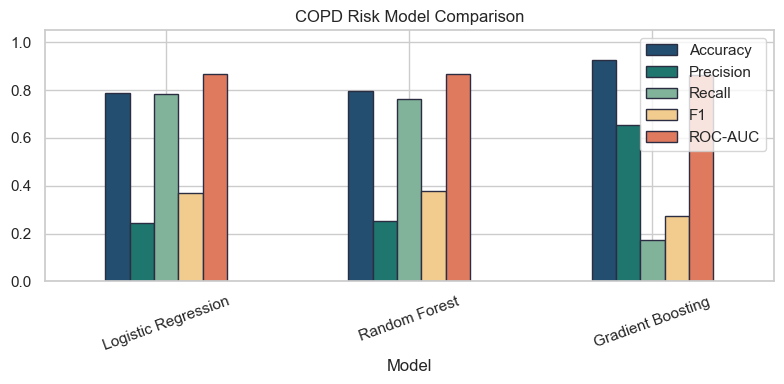

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].plot(
    kind='bar', color=METRIC_PALETTE, edgecolor=EDGE, ax=ax,
)
ax.set_title('COPD Risk Model Comparison')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(FIG_DIR / '07_model_comparison.png', dpi=150)
plt.show()

## Step 9 - Pick the Best Model and Tune the Threshold

The best model is selected by ROC-AUC. With a default 0.5 threshold and class imbalance
of ~8 percent, recall and F1 are weak. We sweep thresholds from 0.10 to 0.90 and choose the
value that maximises F1 on the test set.

In [15]:
best_name = results_df.iloc[0]['Model']
best_pipe = fitted[best_name]
proba = best_pipe.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)
f1_scores = [f1_score(y_test, (proba >= t).astype(int)) for t in thresholds]
best_idx = int(np.argmax(f1_scores))
best_threshold = float(thresholds[best_idx])
print(f'Best model     : {best_name}')
print(f'Best threshold : {best_threshold:.2f}')
print(f'Best F1        : {f1_scores[best_idx]:.4f}')

Best model     : Logistic Regression
Best threshold : 0.77
Best F1        : 0.4528


### 9.1 Threshold tuning curve

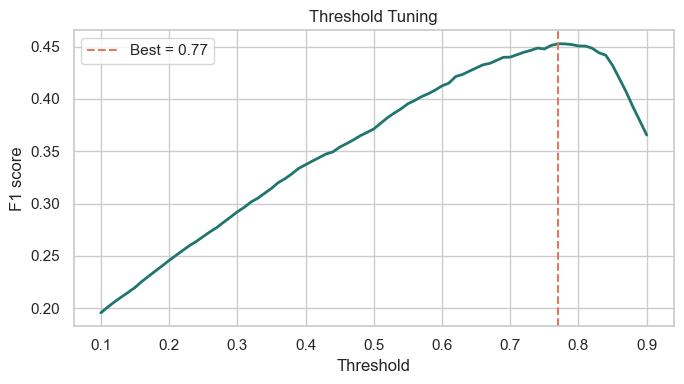

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, f1_scores, color=COPD_NEG, linewidth=2)
ax.axvline(best_threshold, color=COPD_POS, linestyle='--',
           label=f'Best = {best_threshold:.2f}')
ax.set_title('Threshold Tuning')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1 score')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '10_threshold_tuning.png', dpi=150)
plt.show()

## Step 10 - Final Evaluation

In [17]:
final_pred = (proba >= best_threshold).astype(int)

metrics = {
    'best_model': best_name,
    'training_rows': int(len(sample)),
    'best_threshold': best_threshold,
    'accuracy': float(accuracy_score(y_test, final_pred)),
    'precision': float(precision_score(y_test, final_pred, zero_division=0)),
    'recall': float(recall_score(y_test, final_pred)),
    'f1': float(f1_score(y_test, final_pred)),
    'roc_auc': float(roc_auc_score(y_test, proba)),
}

for k, v in metrics.items():
    if isinstance(v, float):
        print(f'{k:<15s}: {v:.4f}')
    else:
        print(f'{k:<15s}: {v}')

print('\nClassification report:')
print(classification_report(y_test, final_pred, target_names=['No COPD', 'COPD']))

best_model     : Logistic Regression
training_rows  : 120000
best_threshold : 0.7700
accuracy       : 0.9000
precision      : 0.4046
recall         : 0.5140
f1             : 0.4528
roc_auc        : 0.8686

Classification report:
              precision    recall  f1-score   support

     No COPD       0.96      0.93      0.94     22068
        COPD       0.40      0.51      0.45      1932

    accuracy                           0.90     24000
   macro avg       0.68      0.72      0.70     24000
weighted avg       0.91      0.90      0.91     24000



### 10.1 Confusion matrix

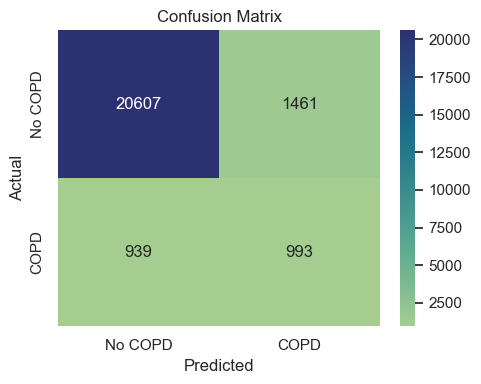

In [18]:
cm = confusion_matrix(y_test, final_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='crest',
    xticklabels=['No COPD', 'COPD'],
    yticklabels=['No COPD', 'COPD'], ax=ax,
)
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
fig.tight_layout()
fig.savefig(FIG_DIR / '08_confusion_matrix.png', dpi=150)
plt.show()

### 10.2 ROC curve

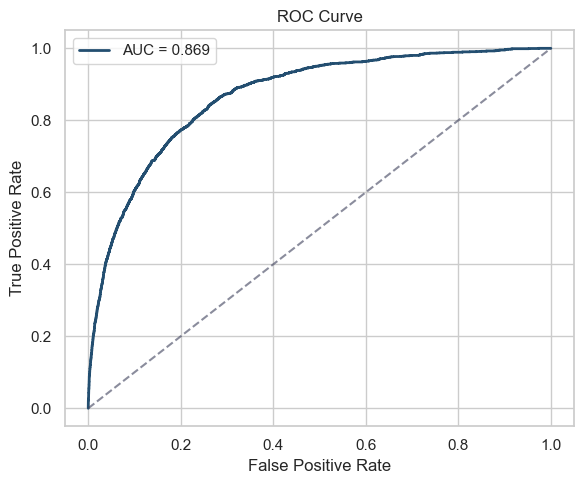

In [19]:
fpr, tpr, _ = roc_curve(y_test, proba)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color=ACCENT, linewidth=2,
        label=f'AUC = {metrics["roc_auc"]:.3f}')
ax.plot([0, 1], [0, 1], '--', color=NEUTRAL, alpha=0.6)
ax.set_title('ROC Curve')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / '09_roc_curve.png', dpi=150)
plt.show()

## Step 11 - Save Deployment Artifacts

We save the fitted pipeline, the feature order, the tuned threshold, and a metadata JSON
with the dropdown options the Flask UI consumes.

In [20]:
joblib.dump(best_pipe, 'copd_risk_model.pkl')
joblib.dump(FEATURE_COLUMNS, 'copd_risk_features.pkl')
joblib.dump(best_threshold, 'copd_risk_threshold.pkl')

options = {
    col: sorted(df[col].fillna('Unknown').astype(str).unique().tolist())
    for col in CATEGORICAL_FEATURES
}
defaults = {
    'Age': 45, 'BMI': 27.5, 'SleepHours': 7,
    'PhysicalHealthDays': 0, 'MentalHealthDays': 0, 'AvgDrinksPerOccasion': 1,
}

metadata = {
    'project': 'COPD Risk Predictor',
    'dataset': 'BRFSS 2022',
    'rows': int(len(df)),
    'columns': int(len(df.columns)),
    'target': TARGET,
    'positive_class_rows': int(df[TARGET].sum()),
    'negative_class_rows': int((df[TARGET] == 0).sum()),
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'feature_columns': FEATURE_COLUMNS,
    'options': options,
    'defaults': defaults,
    'model_results': results_df.to_dict(orient='records'),
    'metrics': metrics,
}
Path('copd_risk_metadata.json').write_text(json.dumps(metadata, indent=2), encoding='utf-8')

print('Saved artifacts:')
for name in ['copd_risk_model.pkl', 'copd_risk_features.pkl',
             'copd_risk_threshold.pkl', 'copd_risk_metadata.json']:
    print(' -', name)

Saved artifacts:
 - copd_risk_model.pkl
 - copd_risk_features.pkl
 - copd_risk_threshold.pkl
 - copd_risk_metadata.json


## Step 12 - Inference Demo

Reload the saved artifacts and run a prediction on a synthetic high-risk patient,
exactly the way `app.py` does at runtime.

In [21]:
loaded_model = joblib.load('copd_risk_model.pkl')
loaded_features = joblib.load('copd_risk_features.pkl')
loaded_threshold = joblib.load('copd_risk_threshold.pkl')

sample_patient = {
    'Age': 68, 'BMI': 34.5, 'SleepHours': 5,
    'PhysicalHealthDays': 20, 'MentalHealthDays': 12, 'AvgDrinksPerOccasion': 0,
    'State': 'California', 'Sex': 'Male', 'AgeGroup': '65-69',
    'GeneralHealth': 'Poor', 'HasPersonalDoctor': 'More than one',
    'CouldNotAffordDoctor': 'Yes', 'RecentCheckup': 'Within past year',
    'ExercisePastMonth': 'No', 'HeartAttack': 'Yes',
    'CoronaryHeartDisease': 'Yes', 'Stroke': 'No',
    'AsthmaEver': 'Yes', 'AsthmaCurrent': 'Yes', 'Depression': 'Yes',
    'KidneyDisease': 'Yes', 'Arthritis': 'Yes', 'Diabetes': 'Yes',
    'MaritalStatus': 'Married', 'Education': 'High school graduate',
    'Employment': 'Retired', 'Income': '$25,000-$35,000',
    'Deaf': 'No', 'Blind': 'No', 'DifficultyDeciding': 'Yes',
    'DifficultyWalking': 'Yes', 'DifficultyDressing': 'No',
    'DifficultyAlone': 'No',
    'Smoked100': 'Yes', 'SmokingFrequency': 'Every day',
    'SmokelessTobacco': 'Not at all', 'AlcoholPast30Days': 'No',
    'BMICategory': 'Obese',
    'CurrentSmokerFlag': 'Yes', 'CurrentECigFlag': 'No',
    'NoPhysicalActivityFlag': 'Yes', 'FairPoorHealthFlag': 'Yes',
    'PhysicalDistressFlag': 'Yes', 'MentalDistressFlag': 'Yes',
    'HasInsuranceFlag': 'Yes', 'Age18To64InsuranceFlag': 'Yes',
    'HeartDiseaseFlag': 'Yes',
}

row = pd.DataFrame([sample_patient])[loaded_features]
probability = float(loaded_model.predict_proba(row)[0, 1])
label = 'Higher COPD Risk' if probability >= loaded_threshold else 'Lower COPD Risk'

print(f'Probability   : {probability:.4f}')
print(f'Threshold     : {loaded_threshold:.2f}')
print(f'Prediction    : {label}')

Probability   : 0.9879
Threshold     : 0.77
Prediction    : Higher COPD Risk


## Step 13 - Conclusion

- Logistic Regression won on ROC-AUC (~0.87) and is also the fastest to train and serve.
- Class imbalance forced us to tune the threshold; F1 peaks around 0.77 of the predicted
  probability, trading some precision for higher recall on the COPD class.
- The pipeline is fully serialised and consumed unchanged by `app.py`, so what runs in this
  notebook is exactly what runs in the web app.

**Limitations.** Self-reported survey data, no spirometry, US-only sample, and the model is
for coursework only - not a clinical tool.